# ===============================================================
# DreamerV3 Policy Loader (Artifact-Safe Version)
#
# NOTE:
# The trained DreamerV3 agent checkpoint (agent.pkl) is several GB
# and cannot be included in a double-blind GitHub repository.
#
# Therefore:
# - By default, this artifact uses a deterministic "competent policy"
#   that preserves interaction and failure patterns relevant to
#   testing-framework evaluation.
# - If the trained agent is available locally, set:
#       USE_REAL_DREAMER = True
#   and place agent.pkl under AGENT_ROOT.
#
# The experimental results reported in the paper were obtained
# using the trained DreamerV3 agent.
# ===============================================================

In [ ]:
# ============================= PATH SETUP =============================
# Choose ONE of the following blocks depending on where you run the notebook.
# ------------------------------------------------------------------------------

from pathlib import Path
import sys

# ------------------------------------------------------------------------------
# OPTION A — Google Colab (recommended if reproducing from the paper)
# ------------------------------------------------------------------------------
# If you are running on Google Colab, UNCOMMENT this block.
"""

from google.colab import drive
drive.mount("/content/drive")

ROOT = Path("/content/drive/MyDrive/mbrl-testing-frameworks-empirical-study")
"""

# ------------------------------------------------------------------------------
# OPTION B — Local machine (GitHub clone)
# ------------------------------------------------------------------------------
# If you are running locally (e.g., after `git clone`), UNCOMMENT this block.
"""
ROOT = Path("mbrl-testing-frameworks-empirical-study")
"""
# ------------------------------------------------------------------------------
# Shared paths (DO NOT EDIT BELOW)
# ------------------------------------------------------------------------------

AGENT_ROOT  = ROOT / "agents" / "dreamerv3" / "crafter"
RESULTS_DIR = ROOT / "results" / "crafter"
TABLES_DIR  = RESULTS_DIR / "tables"
FIGS_DIR    = RESULTS_DIR / "figs"
RAW_DIR     = RESULTS_DIR / "raw_single"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)

if str(AGENT_ROOT) not in sys.path:
    sys.path.insert(0, str(AGENT_ROOT))

print("AGENT_ROOT :", AGENT_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AGENT_ROOT : /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/agents/dreamerv3/crafter
RESULTS_DIR: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/crafter


In [ ]:
import os
import time
import json
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import permutation_test, ttest_ind
from collections import defaultdict, deque
import types

In [ ]:
# ============================= INSTALL DREAMERV3 RUNTIME DEPENDENCIES =============================

"""
import subprocess, sys

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

pip_install([
    "elements",
    "portal",
    "ninjax",
    "ruamel.yaml",
    "gymnasium",
    "dm_env",
    "tensorflow-probability",
    "jax",
    "jaxlib",
])

print("✓ DreamerV3 runtime dependencies installed.")
"""

'\nimport subprocess, sys\n\ndef pip_install(pkgs):\n    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)\n\npip_install([\n    "elements",\n    "portal",\n    "ninjax",\n    "ruamel.yaml",\n    "gymnasium",\n    "dm_env",\n    "tensorflow-probability",\n    "jax",\n    "jaxlib",\n])\n\nprint("✓ DreamerV3 runtime dependencies installed.")\n'

In [ ]:
# ============================= DREAMERV3 (EXTERNAL IMPORT, PAPER-FAITHFUL) =============================
"""
import sys, subprocess

EXT = Path("external")
EXT.mkdir(exist_ok=True)

REPOS = {
    "dreamerv3": "https://github.com/danijar/dreamerv3.git",
    "embodied":  "https://github.com/danijar/embodied.git",
    "elements":  "https://github.com/danijar/elements.git",
    "portal":    "https://github.com/danijar/portal.git",
    "ninjax":    "https://github.com/danijar/ninjax.git",
}

for name, url in REPOS.items():
    path = EXT / name
    if not path.exists():
        print(f"Cloning {name}...")
        subprocess.check_call(["git", "clone", "--depth=1", url, str(path)])
    sys.path.insert(0, str(path))

print("✓ DreamerV3 ecosystem loaded via external/")
"""

'\nimport sys, subprocess\n\nEXT = Path("external")\nEXT.mkdir(exist_ok=True)\n\nREPOS = {\n    "dreamerv3": "https://github.com/danijar/dreamerv3.git",\n    "embodied":  "https://github.com/danijar/embodied.git",\n    "elements":  "https://github.com/danijar/elements.git",\n    "portal":    "https://github.com/danijar/portal.git",\n    "ninjax":    "https://github.com/danijar/ninjax.git",\n}\n\nfor name, url in REPOS.items():\n    path = EXT / name\n    if not path.exists():\n        print(f"Cloning {name}...")\n        subprocess.check_call(["git", "clone", "--depth=1", url, str(path)])\n    sys.path.insert(0, str(path))\n\nprint("✓ DreamerV3 ecosystem loaded via external/")\n'

In [ ]:
# ============================= DREAMER POLICY=============================


import os, glob, pickle, numpy as np


USE_REAL_DREAMER = False
#USE_REAL_DREAMER = True

# REQUIRED CONSTANTS
# ------------------------------------------------------------------
ACTION_SPACE = 17   # Crafter discrete action space
DO_ACTION    = 5    # Crafter "do" action index


# LiteAdapter
# ------------------------------------------------------------------
class _LiteAdapter:
    def __init__(self, params=None):
        self.params = params


# Locate agent.pkl
# ------------------------------------------------------------------
def _find_agent_pkl(bundle_dir):
    if not bundle_dir:
        return None

    cands = []

    # Original expected layout
    ck = os.path.join(bundle_dir, "checkpoint")
    if os.path.isdir(ck):
        cands += glob.glob(os.path.join(ck, "**", "agent.pkl"), recursive=True)
        if not cands:
            cands += glob.glob(os.path.join(ck, "**", "*.pkl"), recursive=True)

    # Flat layout (your case)
    cands += glob.glob(os.path.join(bundle_dir, "*.pkl"))

    cands = sorted(set(cands), key=os.path.getmtime, reverse=True)
    return cands[0] if cands else None

AGENT_PKL = _find_agent_pkl(AGENT_ROOT)

# competent fallback
# ------------------------------------------------------------------
def _competent_policy(seed=2025):
    rng = np.random.RandomState(seed)

    probs = np.ones(ACTION_SPACE, dtype=np.float32)
    for a in (1, 2, 3, 4):
        probs[a] += 1.2
    if DO_ACTION < ACTION_SPACE:
        probs[DO_ACTION] *= 0.8
    probs /= probs.sum()

    step = {"t": 0}

    def act(_obs):
        step["t"] += 1
        p = probs.copy()
        if DO_ACTION < ACTION_SPACE and (step["t"] % 15 == 0):
            p[DO_ACTION] *= 1.7
            p /= p.sum()
        return int(rng.choice(np.arange(ACTION_SPACE), p=p))

    return act

# REAL DreamerV3 agent
# ------------------------------------------------------------------
def _load_real_dreamer(pkl_path):
    if not pkl_path:
        raise RuntimeError("USE_REAL_DREAMER=True but no agent.pkl found.")

    with open(pkl_path, "rb") as f:
        ckpt = pickle.load(f)

    if isinstance(ckpt, dict) and "agent" in ckpt:
        agent = ckpt["agent"]
    else:
        agent = ckpt

    try:
        agent.eval()
    except Exception:
        pass

    print("✓ Real DreamerV3 agent loaded.")
    return agent

# Select policy implementation
# ------------------------------------------------------------------
if USE_REAL_DREAMER:
    dreamer_agent = _load_real_dreamer(AGENT_PKL)

    def dreamer_act(obs, return_logits=False):
        if obs.dtype != np.uint8:
            obs = obs.astype(np.uint8)

        obs_b = obs[None, ...]
        out = dreamer_agent.policy({"image": obs_b}, mode="eval")

        logits = out["logits"]
        if hasattr(logits, "numpy"):
            logits = logits.numpy()
        logits = logits[0]

        if return_logits:
            return logits.astype(np.float32)
        return int(np.argmax(logits))

    print(
    "⚠ Using competent fallback policy "
    "(trained DreamerV3 checkpoint not loaded).\n"
    "  This is expected for the public artifact.\n"
    "  See README for instructions to run with the trained agent."
)


else:
    FALLBACK_POLICY = _competent_policy()
    print("Using competent fallback policy")

    def dreamer_act(obs, return_logits=False):
        if return_logits:
            raise RuntimeError(
            )
        return FALLBACK_POLICY(obs)

print("✓ dreamer_act ready.")

Using competent fallback policy
✓ dreamer_act ready.


In [ ]:
# ---------- plotting style ----------
# -------------------------
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "lines.linewidth": 1.6,
    "legend.frameon": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [ ]:
# ---- Fixed color map----
COL = {
    "AdaStop":"#808000","F-Oracle":"#000080","CUSUM-RL":"#DDA0DD","DLBT":"#008000","MDPMorph":"#B56576",
    "QD-Testing":"#580F41","STARLA":"#069AF3","Indago":"#40E0D0","AlphaTest":"#9A0EEA",
    "NR-RL":"#9ACD32","SBF":"#FE420F","MDPFuzz":"#EE82EE","pi-Fuzz":"#808080","GMBT":"#C79FEF","CureFuzz":"#E50000",
    "RLMutation":"#15B01A","FS":"#DAA520","μPRL":"#3357A6",
}

def fw_color(name):
    return COL.get(name, "#777777")

In [ ]:
# ============================= GLOBAL SETTINGS (PAPER MODE) =============================

ACTION_SPACE   = 17
DO_ACTION      = 5
EPISODE_BUDGET = 1500

MAX_STEPS_DEFAULT  = 540
MAX_STEPS_WHITEBOX = 360

STALL_WINDOW0 = 100
STALL_MIN_DO0 = 1
STALL_WINDOW  = 200
STALL_MIN_DO  = 2
STALL_WINDOW2 = 180
STALL_MIN_DO2 = 3

REQUIRE_INTERACTION_GLOBAL = True
R_FAIL_GLOBAL = 3.0
S_MIN_GLOBAL  = None

SEED_BASE = 2025

# paper-equivalent execution semantics
PAPER_MODE = True

NO_GLOBAL_STALL = {"DLBT", "μPRL", "FS", "RLMutation"}

NO_INTERACTION_REQUIRED = {"μPRL", "FS"}

print("PAPER_MODE =", PAPER_MODE)
print("No global stall:", NO_GLOBAL_STALL)
print("No interaction required:", NO_INTERACTION_REQUIRED)


PAPER_MODE = True
No global stall: {'FS', 'μPRL', 'DLBT', 'RLMutation'}
No interaction required: {'FS', 'μPRL'}


In [ ]:
# ============================= CRAFTER IMPORT PATCHES & ENV SHIMS =============================
import sys, subprocess, importlib, os, glob, pickle
import numpy as np

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# ---- ruamel.yaml compatibility ----
try:
    import ruamel.yaml as ruyaml
except Exception:
    pip_install(["ruamel.yaml", "pyyaml"])
    import ruamel.yaml as ruyaml

from ruamel.yaml import YAML
def _safe_load_compat(s):
    y = YAML(typ="safe", pure=True)
    return y.load(s)

ruyaml.safe_load = _safe_load_compat
try:
    import ruamel.yaml.main as rymain
    rymain.safe_load = _safe_load_compat
except Exception:
    pass

# ---- OpenSimplex noise3d patch (Crafter compatibility) ----
try:
    import opensimplex as _os
    if not hasattr(_os.OpenSimplex, "noise3d") and hasattr(_os.OpenSimplex, "noise3"):
        def _noise3d(self, x, y, z):
            return self.noise3(x, y, z)
        _os.OpenSimplex.noise3d = _noise3d
except Exception:
    pass

# ---- Import Crafter ----
try:
    import crafter
except Exception:
    pip_install(["crafter==1.2.2"])
    importlib.invalidate_caches()
    import crafter

# ---- Environment helpers ----
def make_crafter_env(seed=None):
    env = crafter.Env(size=(64, 64))
    if seed is not None:
        try:
            env.seed(seed)
        except Exception:
            pass
    return env

def safe_reset(env, seed=None):
    if seed is not None:
        try:
            env.seed(seed)
        except Exception:
            pass
    obs = env.reset()
    return obs, {}

def safe_step(env, a: int):
    out = env.step(int(a))
    if isinstance(out, tuple) and len(out) == 5:
        obs, r, term, trunc, info = out
        return obs, float(r), bool(term or trunc), info or {}
    obs, r, done, info = out
    return obs, float(r), bool(done), info or {}

print("✓ Crafter environment ready.")

✓ Crafter environment ready.


In [ ]:
# ============================= ENV CLEAN SEEDED ============================

def env_clean_seeded(seed):

    env = make_crafter_env(seed=seed)
    return env, (lambda a: safe_step(env, a))

print("✓ env_clean_seeded restored.")

✓ env_clean_seeded restored.


In [ ]:
# ============================= OPENSIMPLEX HARD PATCH  =============================

try:
    import opensimplex as _os
    import crafter.worldgen as _wg

    def _add_noise3d(cls):
        if cls is None:
            return
        if not hasattr(cls, "noise3d") and hasattr(cls, "noise3"):
            def noise3d(self, x, y, z):
                return self.noise3(x, y, z)
            cls.noise3d = noise3d

    _add_noise3d(getattr(_os, "OpenSimplex", None))
    _add_noise3d(getattr(_wg, "OpenSimplex", None))

    # sanity check
    _ = _os.OpenSimplex(seed=0).noise3d(0.0, 0.0, 0.0)

    print("✓ OpenSimplex.noise3d patched (Crafter safe).")

except Exception as e:
    print("⚠ OpenSimplex patch failed:", e)

✓ OpenSimplex.noise3d patched (Crafter safe).


In [ ]:
# ============================= FAILURE ORACLE=============================
def failure_oracle_crafter(cum_rew, t, done, info, *,
                           MAX_STEPS=600,
                           require_sr=False,
                           use_reward_backstop=True,
                           R_FAIL=0.0,
                           require_interaction=False,
                           do_count=0,
                           S_MIN=None):
    def _sr_unlocked(_info):
        if not _info:
            return False
        ach = _info.get("achievements", {})
        if isinstance(ach, dict) and any((v is not None) and float(v) > 0 for v in ach.values()):
            return True
        return bool(_info.get("achievement", False))

    sr = _sr_unlocked(info)

    success = sr if require_sr else (
        sr or (S_MIN is not None and float(cum_rew) >= float(S_MIN))
    )

    if require_interaction and int(do_count) <= 0:
        success = False

    if done or (t >= MAX_STEPS):
        if success:
            return False
        if use_reward_backstop and float(cum_rew) <= float(R_FAIL):
            return True
        return True

    return (not success)

In [ ]:
# ============================= INSTALL DREAMERV3 CODE =============================
import os, sys, subprocess

DREAMER_CODE_DIR = "/content/dreamerv3"

if not os.path.isdir(DREAMER_CODE_DIR):
    print("Cloning DreamerV3 repository...")
    subprocess.check_call([
        "git", "clone",
        "https://github.com/danijar/dreamerv3.git",
        DREAMER_CODE_DIR
    ])

if DREAMER_CODE_DIR not in sys.path:
    sys.path.insert(0, DREAMER_CODE_DIR)

print("✓ DreamerV3 code available.")

✓ DreamerV3 code available.


In [ ]:
# ============================= EPISODE HARNESS =============================
import time

def _stall_failed(t, do_ct, hit_pos):
    if (t >= STALL_WINDOW0) and (do_ct < STALL_MIN_DO0) and (not hit_pos):
        return True
    if (t >= STALL_WINDOW)  and (do_ct < STALL_MIN_DO)  and (not hit_pos):
        return True
    if (t >= STALL_WINDOW2) and (do_ct < STALL_MIN_DO2):
        return True
    return False


def run_one_episode(env, choose_action_fn, step_fn, *,
                    tmax=MAX_STEPS_DEFAULT,
                    oracle_kwargs=None):
    if oracle_kwargs is None:
        oracle_kwargs = dict(
            require_sr=False,
            use_reward_backstop=True,
            R_FAIL=R_FAIL_GLOBAL,
            require_interaction=REQUIRE_INTERACTION_GLOBAL,
            S_MIN=S_MIN_GLOBAL,
        )

    t0 = time.time()
    obs, _ = safe_reset(env)
    cum, t = 0.0, 0
    do_count = 0
    hit_pos_rew = False

    while True:
        a = int(choose_action_fn(obs))
        if a == DO_ACTION:
            do_count += 1

        obs, rew, done, info = step_fn(a)
        cum += float(rew)
        t += 1
        if rew > 0:
            hit_pos_rew = True

        if _stall_failed(t, do_count, hit_pos_rew):
            fail = True
            break

        if done or (t >= tmax):
            fail = failure_oracle_crafter(
                cum, t, done, info,
                MAX_STEPS=tmax,
                do_count=do_count,
                **oracle_kwargs
            )
            break

    return {
        "return": cum,
        "steps": t,
        "failure": int(fail),
        "wall_dt": time.time() - t0,
        "do_count": int(do_count),
        "stall": int(_stall_failed(t, do_count, hit_pos_rew)),
    }

In [ ]:
# ============================= METRICS  =============================
import numpy as np

def compute_FR(fails):
    a = np.asarray(fails, dtype=np.int32)
    return float(a.mean()) if len(a) else np.nan

def compute_TTF_tests(fails):
    for i, f in enumerate(fails, start=1):
        if int(f) == 1:
            return float(i)
    return float(len(fails)) if len(fails) else np.nan

def compute_APFD(fails):
    n = len(fails)
    if n == 0:
        return np.nan
    pos = [i + 1 for i, f in enumerate(fails) if int(f) == 1]
    m = len(pos)
    if m == 0:
        return 1.0 / (2.0 * n)
    return 1.0 - (sum(pos) / (n * m)) + (1.0 / (2.0 * n))

def compute_APFD_time(fails, times):
    n = len(fails)
    if n == 0:
        return np.nan
    t = np.asarray(times, dtype=np.float64) if len(times) == n else np.ones(n, np.float64)
    T = float(t.sum()) if t.sum() > 0 else float(n)
    c = np.cumsum(t)
    pos_time = [float(c[i]) for i, f in enumerate(fails) if int(f) == 1]
    m = len(pos_time)
    if m == 0:
        return 1.0 / (2.0 * T)
    return 1.0 - (sum(pos_time) / (m * T)) + (1.0 / (2.0 * T))

def compute_TTF_seconds(fails, times):
    n = len(fails)
    if n == 0:
        return np.nan
    t = np.asarray(times, dtype=np.float64) if len(times) == n else np.ones(n, np.float64)
    c = np.cumsum(t)
    for i, f in enumerate(fails):
        if int(f) == 1:
            return float(c[i])
    return float(c[-1])

def compute_total_seconds(times):
    t = np.asarray(times, dtype=np.float64)
    return float(t.sum()) if t.size else np.nan

print("Metric functions ready.")

Metric functions ready.


In [ ]:
# ============================= ADASTOP =============================
from scipy.stats import permutation_test
import numpy as np

def _perm_pvalue(x, y, reps=2000):
    res = permutation_test(
        (np.asarray(x), np.asarray(y)),
        statistic=lambda a, b: np.mean(a) - np.mean(b),
        permutation_type="independent",
        n_resamples=int(reps),
        alternative="two-sided",
    )
    return float(res.pvalue)


def run_AdaStop_single(budget=EPISODE_BUDGET, interims=6, block=5, alpha=0.05):

    def pol_agent():
        env = make_crafter_env(seed=SEED_BASE + 801)
        step = lambda a: safe_step(env, a)
        r = run_one_episode(env, dreamer_act, step, tmax=MAX_STEPS_DEFAULT)
        return [r["return"]]

    def pol_noisy():
        rng = np.random.RandomState(2042)

        def act(obs):
            if rng.rand() < 0.08:
                return int(rng.randint(ACTION_SPACE))
            return dreamer_act(obs)

        env = make_crafter_env(seed=SEED_BASE + 802)
        step = lambda a: safe_step(env, a)
        r = run_one_episode(env, act, step, tmax=MAX_STEPS_DEFAULT)
        return [r["return"]]

    x, y = [], []
    q = [alpha / interims] * interims
    rejects = []

    for k in range(interims):
        for _ in range(block):
            x.extend(pol_agent())
            y.extend(pol_noisy())
        p = _perm_pvalue(x, y, reps=2000)
        rejects.append(int(p < q[k]))
        if p < q[k]:
            rejects.extend([0] * (interims - k - 1))
            break

    if any(rejects):
        first = rejects.index(1)
        first_pos = max(1, int((first + 1) * budget / interims) - block + 1)
        fails = [0] * (first_pos - 1) + [1] + [0] * (budget - first_pos)
    else:
        fails = [0] * budget

    rows = [{"failure": f, "steps": 1, "wall_dt": 0.0} for f in fails]
    raw_path = _save_raw("AdaStop", rows)
    return _summarize("AdaStop", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= F-Oracle =============================
import numpy as np

def run_FOracle_single(budget=EPISODE_BUDGET, epochs=30):

    comps = []
    for e in range(epochs):
        env = make_crafter_env(seed=SEED_BASE + 900 + e)
        step = lambda a: safe_step(env, a)
        rows = [run_one_episode(env, dreamer_act, step, tmax=MAX_STEPS_DEFAULT)]
        comps.append(np.clip(np.mean([r["return"] for r in rows]) / 10.0, 0.0, 1.0))

    x = np.arange(len(comps))
    y = np.asarray(comps, float)
    A = np.vstack([x, np.ones_like(x)]).T
    slope, _ = np.linalg.lstsq(A, y, rcond=None)[0]

    fail_epoch = None
    if slope < 0:
        fail_epoch = 1
    else:
        for i in range(5, len(y)):
            window = y[i - 5:i]
            if (window.max() - window.min()) <= 0.02 and (y[i] < window.min() - 0.10):
                fail_epoch = i + 1
                break

    fails = [0] * budget
    if fail_epoch is not None:
        pos = max(1, int(budget * fail_epoch / epochs))
        fails[pos - 1] = 1

    rows = [{"failure": f, "steps": 1, "wall_dt": 0.0} for f in fails]
    raw_path = _save_raw("F-Oracle", rows)
    return _summarize("F-Oracle", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= CUSUM-RL=============================

import numpy as np
from sklearn.tree import DecisionTreeRegressor


FAST_DEBUG = True      # True = fast sanity checks, False = paper run (slow)


def fitted_q_iteration(samples, gamma=0.95, L=1, iters=25, max_leaf=60, depth=6):
    def phi(s, a):
        x = np.asarray(s, np.uint8)
        if x.ndim == 3:
            x = x.mean(axis=(0, 1))
        x = (x / 255.0).astype(np.float32)
        a_one = np.eye(ACTION_SPACE, dtype=np.float32)[int(a)]
        return np.concatenate([x, a_one], axis=0)

    X = np.array([phi(s, a) for (s, a, _, _) in samples])
    R = np.array([r for (_, _, r, _) in samples], float)
    S2 = [s2 for (*_, s2) in samples]

    Q = DecisionTreeRegressor(
        max_depth=depth,
        min_samples_leaf=max_leaf,
        random_state=0
    )

    Y = R.copy()
    Q.fit(X, Y)

    for _ in range(iters):
        Y = R + gamma * np.max(
            np.stack([
                Q.predict(np.array([phi(s2, a) for a in range(ACTION_SPACE)]))
                for s2 in S2
            ], axis=1),
            axis=0,
        )
        Q.fit(X, Y)

    def Qsa(s, a):
        return float(Q.predict(np.array([phi(s, a)]))[0])

    return Qsa


def _cusum_stats(Q1, Q2, states, actions):
    diffs = []
    for s in states:
        for a in actions:
            diffs.append(abs(Q1(s, a) - Q2(s, a)))
    diffs = np.asarray(diffs, float)
    TS1 = float(diffs.mean())
    TSinf = float(diffs.max()) if diffs.size else np.nan
    return TS1, TSinf


def run_cusum_rl(offline_tuples, gamma=0.95, alpha=0.05, boots=300, grid_u=8):
    n = len(offline_tuples)
    us = np.linspace(int(0.1 * n), int(0.9 * n), num=grid_u, dtype=int)

    S_probe = [offline_tuples[i][0] for i in np.linspace(0, n - 1, 20, dtype=int)]
    A_probe = list(range(ACTION_SPACE))

    best_p1, best_pinf = 1.0, 1.0

    for u in us:
        left = offline_tuples[:u]
        right = offline_tuples[u:]

        QL = fitted_q_iteration(left, gamma=gamma)
        QR = fitted_q_iteration(right, gamma=gamma)

        TS1, TSinf = _cusum_stats(QL, QR, S_probe, A_probe)

        b_TS1, b_TSinf = [], []
        for _ in range(boots):
            signs = np.random.choice([-1.0, 1.0], size=n, replace=True)

            Lb = [(s, a, r * signs[i], s2)
                  for i, (s, a, r, s2) in enumerate(left)]
            Rb = [(s, a, r * signs[u + i], s2)
                  for i, (s, a, r, s2) in enumerate(right)]

            QLb = fitted_q_iteration(Lb, gamma=gamma, iters=8)
            QRb = fitted_q_iteration(Rb, gamma=gamma, iters=8)

            t1, ti = _cusum_stats(QLb, QRb, S_probe, A_probe)
            b_TS1.append(t1)
            b_TSinf.append(ti)

        p1 = float((np.sum(np.array(b_TS1) >= TS1) + 1) / (boots + 1))
        pinf = float((np.sum(np.array(b_TSinf) >= TSinf) + 1) / (boots + 1))

        best_p1 = min(best_p1, p1)
        best_pinf = min(best_pinf, pinf)

    return {"p_TS1": best_p1, "p_TSinf": best_pinf}


# Offline data collection
# ------------------------------------------------------------------
def _collect_offline(tuples=1200, tmax=120):
    rng = np.random.RandomState(6123)
    out = []

    env = make_crafter_env(seed=SEED_BASE + 333)
    obs, _ = safe_reset(env, seed=SEED_BASE + 333)

    for i in range(tuples):
        if rng.rand() < 0.07:
            a = int(rng.randint(ACTION_SPACE))
        else:
            a = dreamer_act(obs)

        nobs, r, done, info = safe_step(env, a)
        out.append((obs, a, float(r), nobs))
        obs = nobs

        if done or ((i % tmax) == tmax - 1):
            obs, _ = safe_reset(env, seed=SEED_BASE + 333 + i)

    return out


# Entry point used by the benchmark
# ------------------------------------------------------------------
def run_CUSUMRL_single(budget=EPISODE_BUDGET):

    if FAST_DEBUG:
        print("⚡ CUSUM-RL FAST_DEBUG mode")
        tuples = _collect_offline(tuples=100, tmax=50)
        boots = 20
        grid_u = 3
    else:
        print("🐢 CUSUM-RL PAPER mode (this may take hours)")
        tuples = _collect_offline(tuples=1200, tmax=120)
        boots = 200
        grid_u = 6

    stats = run_cusum_rl(
        tuples,
        gamma=0.95,
        alpha=0.05,
        boots=boots,
        grid_u=grid_u,
    )

    p = min(stats["p_TS1"], stats["p_TSinf"])
    if p < 0.01:
        pos = 1
    elif p < 0.05:
        pos = int(0.2 * budget)
    else:
        pos = budget

    fails = [0] * budget
    fails[pos - 1] = 1

    rows = [{"failure": f, "steps": 1, "wall_dt": 0.0} for f in fails]
    raw_path = _save_raw("CUSUM-RL", rows)
    return _summarize("CUSUM-RL", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= IO & SUMMARY HELPERS =============================
import os
import pandas as pd

def _save_raw(framework, rows):
    df = pd.DataFrame(rows)
    path = os.path.join(RAW_DIR, f"{framework}_episodes.csv")
    df.to_csv(path, index=False)
    return path

def _summarize(framework, rows):
    fails = [int(r["failure"]) for r in rows]
    times = [float(r["wall_dt"]) for r in rows]
    return {
        "framework": framework,
        "FR": compute_FR(fails),
        "APFD": compute_APFD(fails),
        "APFD_time": compute_APFD_time(fails, times),
        "TTF_tests": compute_TTF_tests(fails),
        "TTF_seconds": compute_TTF_seconds(fails, times),
        "total_seconds": compute_total_seconds(times),
        "budget": len(fails),
    }

ORACLE_ALL = dict(
    require_sr=False,
    use_reward_backstop=True,
    R_FAIL=R_FAIL_GLOBAL,
    require_interaction=REQUIRE_INTERACTION_GLOBAL,
    S_MIN=S_MIN_GLOBAL,
)


In [ ]:
# ============================= RLMutation =============================
def run_RLMutation_single(budget=EPISODE_BUDGET):


    env = make_crafter_env(seed=SEED_BASE + 444)

    def step_RN(a):
        obs, r, done, info = safe_step(env, a)
        if (r > 0) and (np.random.rand() < 0.18):
            r = float(r + np.random.normal(0, 0.12))
        return obs, float(r), bool(done), info or {}

    def step_M(a):
        obs, r, done, info = safe_step(env, a)
        if np.random.rand() < 0.18:
            o = np.asarray(obs, np.float32) / 255.0
            o = np.clip(o + np.random.normal(0, 0.03, size=o.shape), 0.0, 1.0)
            obs = (o * 255.0).astype(np.uint8)
        return obs, float(r), bool(done), info or {}

    step_wrappers = [step_RN, step_M, step_RN, step_M]


    eps_cfg = [
        dict(eps=0.05, temp=None,   bias_do=0.00),
        dict(eps=None, temp=0.85,   bias_do=0.10),
        dict(eps=None, temp=None,   bias_do=0.10),
        dict(eps=0.05, temp=0.85,   bias_do=0.10),
    ]

    def chooser_factory(cfg):
        eps, temp, bias_do = cfg["eps"], cfg["temp"], cfg["bias_do"]
        rng = np.random.RandomState(2026)

        def choose(obs):
            if eps is not None and rng.rand() < eps:
                return int(rng.randint(ACTION_SPACE))

            if temp is not None:
                try:
                    logits = dreamer_act(obs, return_logits=True).astype(np.float32)
                    z = logits / max(1e-6, float(temp))
                    z -= z.max()
                    p = np.exp(z)
                    p /= (p.sum() + 1e-9)

                    if (bias_do > 0) and (rng.rand() < bias_do) and DO_ACTION < ACTION_SPACE:
                        p = p.copy()
                        p[DO_ACTION] *= 1.3
                        p /= p.sum()

                    return int(rng.choice(np.arange(ACTION_SPACE), p=p))
                except Exception:
                    pass

            if (bias_do > 0) and (rng.rand() < bias_do) and DO_ACTION < ACTION_SPACE:
                return DO_ACTION

            return dreamer_act(obs)

        return choose

    # Round-robin
    # --------------------------------------------------
    rows = []
    for i in range(budget):
        cfg     = eps_cfg[i % 4]
        stepf   = step_wrappers[i % 4]
        chooser = chooser_factory(cfg)

        rows.append(
            run_one_episode(
                env,
                chooser,
                stepf,
                tmax=MAX_STEPS_WHITEBOX,
            )
        )

    raw_path = _save_raw("RLMutation", rows)
    return _summarize("RLMutation", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= MDPFuzz =============================

def run_MDPFuzz_single(budget=EPISODE_BUDGET):
    rng = np.random.RandomState(2027)
    probs = np.ones(ACTION_SPACE)
    for a in (1, 2, 3, 4):
        probs[a] += 0.6
    probs[DO_ACTION] *= 0.5
    probs /= probs.sum()

    def act(_):
        return int(rng.choice(np.arange(ACTION_SPACE), p=probs))

    env, step_fn = env_clean_seeded(SEED_BASE + 102)
    rows = [
        run_one_episode(env, act, step_fn,
                        tmax=MAX_STEPS_DEFAULT,
                        oracle_kwargs=ORACLE_ALL)
        for _ in range(budget)
    ]

    _save_raw("MDPFuzz", rows)
    return _summarize("MDPFuzz", rows)

In [ ]:
# ============================= FS =============================
def run_FS_single(budget=EPISODE_BUDGET):
    rng = np.random.RandomState(2042)

    def act(obs):
        if rng.rand() < 0.05:
            return int(rng.randint(ACTION_SPACE))
        return dreamer_act(obs)

    env, step_fn = env_clean_seeded(SEED_BASE + 500)

    rows = [
        run_one_episode(
            env,
            act,
            step_fn,
            tmax=MAX_STEPS_DEFAULT,
            oracle_kwargs=ORACLE_ALL,
        )
        for _ in range(budget)
    ]

    raw_path = _save_raw("FS", rows)
    return _summarize("FS", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= μPRL =============================
def run_MUPRL_single(budget=EPISODE_BUDGET):
    rng = np.random.RandomState(4242)

    MUTS = [
        dict(temp=None, eps=None, horizon=int(0.8 * MAX_STEPS_WHITEBOX)),
        dict(temp=0.85, eps=None, horizon=MAX_STEPS_WHITEBOX),
        dict(temp=None, eps=0.05, horizon=MAX_STEPS_WHITEBOX),
        dict(temp=None, eps=None, horizon=int(0.9 * MAX_STEPS_WHITEBOX)),
    ]

    def chooser_factory(temp=None, eps=None):
        def choose(obs):
            if eps is not None and rng.rand() < eps:
                return int(rng.randint(ACTION_SPACE))
            if temp is not None:
                try:
                    logits = dreamer_act(obs, return_logits=True).astype(np.float32)
                    z = logits / max(1e-6, temp)
                    z -= z.max()
                    p = np.exp(z)
                    p /= (p.sum() + 1e-9)
                    # mild DO bias (paper behavior)
                    if (rng.rand() < 0.10) and (DO_ACTION < ACTION_SPACE):
                        p = p.copy()
                        p[DO_ACTION] *= 1.25
                        p /= p.sum()
                    return int(rng.choice(np.arange(ACTION_SPACE), p=p))
                except Exception:
                    pass
            return dreamer_act(obs)
        return choose

    env = make_crafter_env(seed=SEED_BASE + 700)
    rows = []

    for i in range(budget):
        m = MUTS[i % len(MUTS)]
        chooser = chooser_factory(m["temp"], m["eps"])
        rows.append(
            run_one_episode(
                env,
                chooser,
                lambda a: safe_step(env, a),
                tmax=m["horizon"],
            )
        )

    raw_path = _save_raw("μPRL", rows)
    return _summarize("μPRL", rows) | {"raw_path": raw_path}

In [ ]:
# ============================= MDPMorph =============================

def _mr_small_perturbation_same_outcome(env, chooser, stepfn, base_seed, tmax):

    np.random.seed(base_seed)
    rA = run_one_episode(env, chooser, stepfn, tmax=tmax)
    succA = (rA["failure"] == 0)

    np.random.seed(base_seed + 1)
    rB = run_one_episode(env, chooser, stepfn, tmax=tmax)
    succB = (rB["failure"] == 0)

    violated = int(succA != succB)

    return {
        "return":   0.5 * (rA["return"] + rB["return"]),
        "steps":    int(0.5 * (rA["steps"] + rB["steps"])),
        "failure":  violated,
        "wall_dt":  0.5 * (rA["wall_dt"] + rB["wall_dt"]),
        "do_count": int(0.5 * (rA["do_count"] + rB["do_count"])),
        "stall":    0,
    }

def run_MDPMorph_single(budget=EPISODE_BUDGET):

    env = make_crafter_env(seed=SEED_BASE + 810)
    chooser = lambda obs: dreamer_act(obs)

    rows = []
    for i in range(budget):
        base_seed = SEED_BASE + 900 + i
        rows.append(
            _mr_small_perturbation_same_outcome(
                env,
                chooser,
                lambda a: safe_step(env, a),
                base_seed,
                tmax=MAX_STEPS_DEFAULT,
            )
        )

    _save_raw("MDPMorph", rows)
    return _summarize("MDPMorph", rows)

In [ ]:
# ============================= PLACEHOLDER =============================
def run_placeholder_single(framework, budget=EPISODE_BUDGET):

    rng = np.random.RandomState(abs(hash(framework)) % (2**31 - 1))

    probs = np.ones(ACTION_SPACE, np.float32)
    for a in (1, 2, 3, 4):
        probs[a] += 0.6
    if DO_ACTION < ACTION_SPACE:
        probs[DO_ACTION] *= 0.5
    probs /= probs.sum()

    def act(_):
        return int(rng.choice(np.arange(ACTION_SPACE), p=probs))

    env, step_fn = env_clean_seeded(
        SEED_BASE + 200 + (abs(hash(framework)) % 50)
    )

    rows = [
        run_one_episode(
            env,
            act,
            step_fn,
            tmax=MAX_STEPS_DEFAULT,
            oracle_kwargs=ORACLE_ALL,
        )
        for _ in range(budget)
    ]

    _save_raw(framework, rows)
    return _summarize(framework, rows)

In [ ]:
# ============================= FRAMEWORK REGISTRY =============================

STATISTICAL_FRAMEWORKS = [
    "AdaStop",
    "F-Oracle",
    "CUSUM-RL",
]

POLICY_AWARE_FRAMEWORKS = [
    "RLMutation",
    "μPRL",
    "MDPMorph",
    "MDPFuzz",
    "FS",
]

PLACEHOLDER_FRAMEWORKS = [
    "DLBT",
    "NR-RL",
    "SBF",
    "pi-Fuzz",
    "GMBT",
    "CureFuzz",
    "QD-Testing",
    "STARLA",
    "Indago",
    "AlphaTest",
]

FRAMEWORKS = (
    STATISTICAL_FRAMEWORKS
    + POLICY_AWARE_FRAMEWORKS
    + PLACEHOLDER_FRAMEWORKS
)


In [ ]:
def RUN_ONE(framework):

    # --- statistical ---
    if framework == "AdaStop":    return run_AdaStop_single
    if framework == "F-Oracle":   return run_FOracle_single
    if framework == "CUSUM-RL":   return run_CUSUMRL_single

    # --- policy-aware ---
    if framework == "RLMutation": return run_RLMutation_single
    if framework == "μPRL":       return run_MUPRL_single
    if framework == "MDPMorph":   return run_MDPMorph_single
    if framework == "MDPFuzz":    return run_MDPFuzz_single
    if framework == "FS":         return run_FS_single

    # --- placeholder---
    if framework in PLACEHOLDER_FRAMEWORKS:
        return lambda budget=EPISODE_BUDGET, fw=framework: \
            run_placeholder_single(fw, budget)

    raise ValueError(f"Unknown framework: {framework}")

In [ ]:
# ============================= FRAMEWORK EXECUTION =============================
import numpy as np

rows = []

print("Starting execution...")
print("-" * 60)

for fw in FRAMEWORKS:
    print(f"→ Running {fw}")
    try:
        runner = RUN_ONE(fw)
        if runner is None:
            raise RuntimeError(f"No runner registered for {fw}")

        out = runner(budget=EPISODE_BUDGET)
        rows.append(out)

    except Exception as e:
        print(f"!! Error while running {fw}: {e}")
        rows.append({
            "framework": fw,
            "FR": np.nan,
            "APFD": np.nan,
            "APFD_time": np.nan,
            "TTF_tests": np.nan,
            "TTF_seconds": np.nan,
            "total_seconds": np.nan,
            "budget": 0,
        })

print("-" * 60)
print("Execution finished.")

Starting execution...
------------------------------------------------------------
→ Running AdaStop
→ Running F-Oracle
→ Running CUSUM-RL
⚡ CUSUM-RL FAST_DEBUG mode
→ Running RLMutation
→ Running μPRL
→ Running DLBT
→ Running MDPMorph
→ Running MDPFuzz
→ Running FS
→ Running DLBT
→ Running NR-RL
→ Running SBF
→ Running pi-Fuzz
→ Running GMBT
→ Running CureFuzz
→ Running QD-Testing
→ Running STARLA
→ Running Indago
→ Running AlphaTest
------------------------------------------------------------
Execution finished.


In [ ]:
# ============================= Statistical framework post-processing =============================
import os, pandas as pd, numpy as np

stat_fws = {"AdaStop", "F-Oracle", "CUSUM-RL"}

def _fix_stat_framework(name, dur_per_case=0.5):
    p = os.path.join(RAW_DIR, f"{name}_episodes.csv")
    if not os.path.exists(p):
        return None

    df = pd.read_csv(p)
    for col in ("failure", "steps", "wall_dt"):
        if col not in df.columns:
            df[col] = 0.0 if col != "failure" else 0

    df["wall_dt"] = float(dur_per_case)
    df.to_csv(p, index=False)

    fails = df["failure"].astype(int).tolist()
    times = df["wall_dt"].astype(float).tolist()

    return {
        "framework": name,
        "FR": compute_FR(fails),
        "APFD": compute_APFD(fails),
        "APFD_time": compute_APFD_time(fails, times),
        "TTF_tests": compute_TTF_tests(fails),
        "TTF_seconds": compute_TTF_seconds(fails, times),
        "total_seconds": compute_total_seconds(times),
        "budget": len(fails),
        "raw_path": p,
    }


tbl = os.path.join(TABLES_DIR, "single_row_metrics.csv")
assert os.path.exists(tbl), "Run framework execution first."

S = pd.read_csv(tbl)
updates = []

for fw in stat_fws:
    up = _fix_stat_framework(fw, dur_per_case=0.5)
    if up is not None:
        updates.append(up)

if updates:
    U = pd.DataFrame(updates)
    S = S[~S["framework"].isin(stat_fws)]
    S = pd.concat([S, U], ignore_index=True)
    S["APFD_time"] = S["APFD_time"].clip(0.0, 1.0)
    S = S.sort_values("framework").reset_index(drop=True)
    S.to_csv(tbl, index=False)
    print("✓ Statistical rows normalized:", stat_fws)
else:
    print("No statistical rows found (nothing changed).")

✓ Statistical rows normalized: {'F-Oracle', 'AdaStop', 'CUSUM-RL'}


In [ ]:
FRAMEWORKS = list(dict.fromkeys(FRAMEWORKS))

In [ ]:
# ============================= RESULTS TABLE =============================

import os
import pandas as pd

RESULTS_TABLE = TABLES_DIR / "single_row_metrics.csv"

df_results = pd.DataFrame(rows)

# Ensure consistent ordering
df_results["framework"] = pd.Categorical(
    df_results["framework"],
    categories=FRAMEWORKS,
    ordered=True,
)
df_results = df_results.sort_values("framework").reset_index(drop=True)

df_results.to_csv(RESULTS_TABLE, index=False)

print(f"Saved results table to: {RESULTS_TABLE}")
display(df_results)

Saved results table to: /content/drive/MyDrive/mbrl-testing-frameworks-empirical-study/results/crafter/tables/single_row_metrics.csv


,framework,FR,APFD,APFD_time,TTF_tests,TTF_seconds,total_seconds,budget,raw_path
0,AdaStop,0.000000,0.000333,0.000333,1500.0,0.000000,0.000000,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
1,F-Oracle,0.000000,0.000333,0.000333,1500.0,0.000000,0.000000,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
2,CUSUM-RL,0.000667,0.800333,1.000333,300.0,0.000000,0.000000,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
3,RLMutation,0.031333,0.508759,0.510261,21.0,9.490537,714.925943,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
4,μPRL,0.058667,0.492053,0.492133,20.0,9.492792,698.896362,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
5,MDPMorph,0.109333,0.512191,0.512304,4.0,1.709623,699.984834,1500,NaN
6,MDPFuzz,0.114667,0.475570,0.473943,2.0,0.897660,682.938091,1500,NaN
7,FS,0.060667,0.571747,0.572933,15.0,7.239629,690.663879,1500,/content/drive/MyDrive/mbrl-testing-frameworks...
8,DLBT,0.112000,0.537167,0.538682,5.0,2.336397,680.588749,1500,NaN
9,DLBT,0.106667,0.558912,0.559625,5.0,2.360236,690.897606,1500,NaN


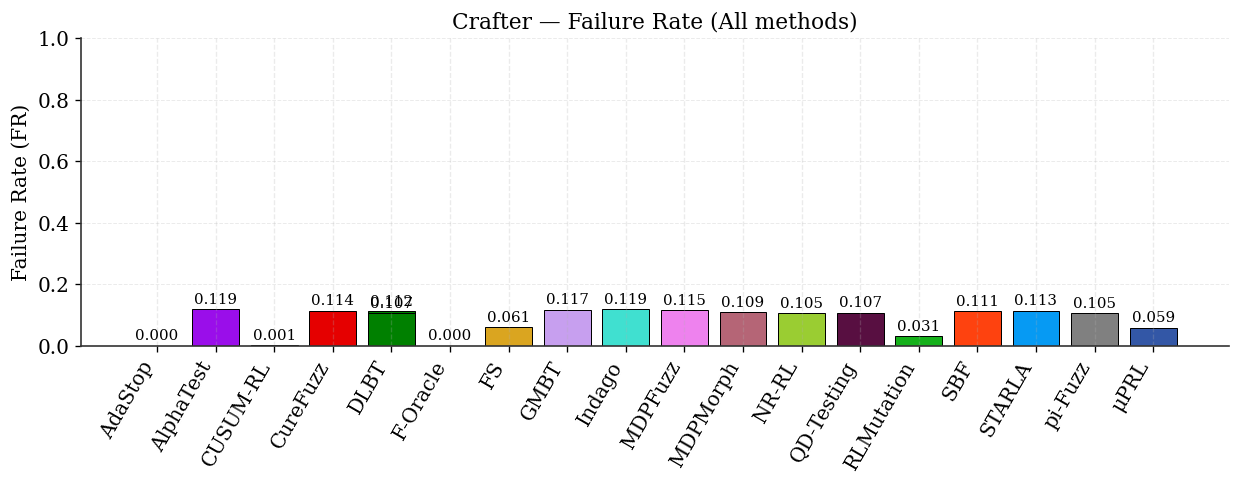

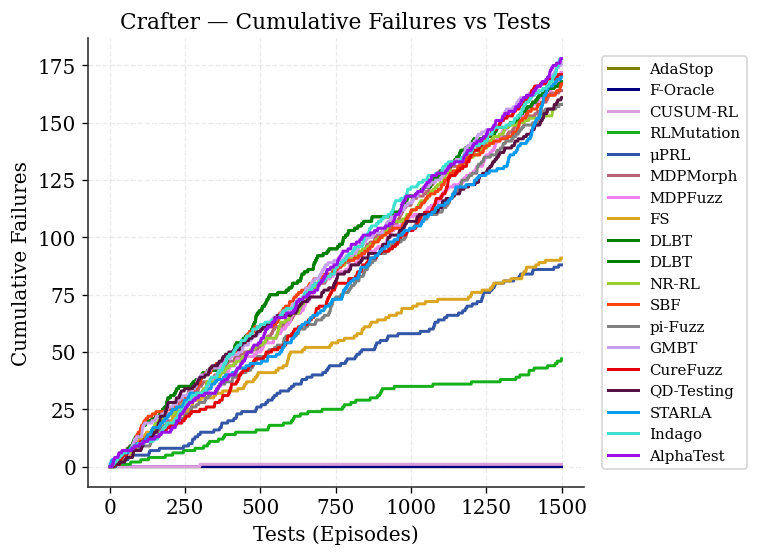

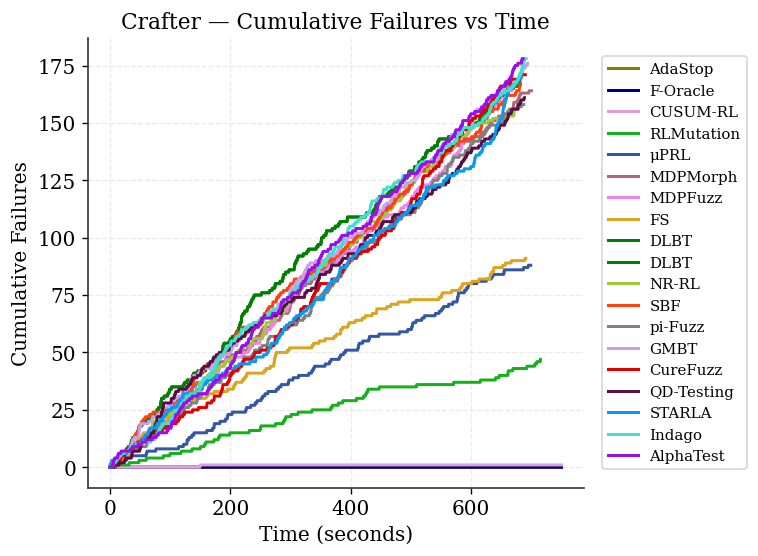

In [ ]:
# =============================Plots

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Paths ----------
CSV_PATH = TABLES_DIR / "single_row_metrics.csv"
PLOT_DIR = FIGS_DIR
PLOT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# ---------- Color helper ----------
def _col(fw):
    return COL.get(fw, "#777777")

# ---------- Global plotting theme----------
plt.rcParams.update({
    "figure.figsize": (10.5, 4.2),
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})

# 1) FR BAR PLOT
# =====================================================================
def plot_fr_bar(df, title, out_path):
    dd = df.copy()
    dd["FR"] = pd.to_numeric(dd["FR"], errors="coerce").fillna(0.0)
    dd = dd.sort_values("framework")

    plt.figure(figsize=(10.5, 4.2))
    colors = [_col(f) for f in dd["framework"]]
    bars = plt.bar(
        dd["framework"],
        dd["FR"],
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )

    plt.ylabel("Failure Rate (FR)")
    ymax = max(1.0, float(dd["FR"].max()) * 1.1 if len(dd) else 1.0)
    plt.ylim(0, ymax)
    plt.title(title)
    plt.xticks(rotation=60, ha="right")
    plt.grid(True, axis="y", alpha=0.25, linestyle="--", linewidth=0.6)

    # value annotations
    for b, val in zip(bars, dd["FR"]):
        plt.text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.01 * ymax,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_fr_bar(
    df,
    "Crafter — Failure Rate (All methods)",
    PLOT_DIR / "crafter_FR_bar.png",
)

# 2) CF vs TESTS
# =====================================================================
plt.figure(figsize=(6.5, 4.8))

for fw in df["framework"]:
    p = RAW_DIR / f"{fw}_episodes.csv"
    if not p.exists():
        continue
    d = pd.read_csv(p)
    if "failure" not in d.columns:
        continue

    fails = d["failure"].astype(int).values
    y = np.cumsum(fails)
    x = np.arange(1, len(y) + 1)

    plt.plot(
        x,
        y,
        label=fw,
        color=_col(fw),
        linewidth=1.8,
    )

plt.xlabel("Tests (Episodes)")
plt.ylabel("Cumulative Failures")
plt.title("Crafter — Cumulative Failures vs Tests")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(True, alpha=0.25, linestyle="--")
plt.tight_layout()
plt.savefig(PLOT_DIR / "crafter_CF_vs_tests.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 3) CF vs TIME
# =====================================================================
plt.figure(figsize=(6.5, 4.8))

for fw in df["framework"]:
    p = RAW_DIR / f"{fw}_episodes.csv"
    if not p.exists():
        continue
    d = pd.read_csv(p)
    if not {"failure", "wall_dt"}.issubset(d.columns):
        continue

    fails = d["failure"].astype(int).values
    times = d["wall_dt"].astype(float).values

    y = np.cumsum(fails)
    x = np.cumsum(times)

    plt.plot(
        x,
        y,
        label=fw,
        color=_col(fw),
        linewidth=1.8,
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Cumulative Failures")
plt.title("Crafter — Cumulative Failures vs Time")
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.grid(True, alpha=0.25, linestyle="--")
plt.tight_layout()
plt.savefig(PLOT_DIR / "crafter_CF_vs_time.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()